# Trabalho prático 1
Implementação e comparação de um algoritmo KNN usando como base a base de dados Iris

## Introdução

Este notebook tem como objetivo implementar e comparar dois classificadores K-Nearest Neighbors (KNN) e plotar matrizes de confusão: uma versão desenvolvida manualmente, sem utilizar a biblioteca pronta, e outra versão usando o algoritmo já implementado pela biblioteca scikit-learn.

A base de dados utilizada será a base Iris, amplamente empregada em tarefas de classificação. Ela contém 150 amostras de flores, distribuídas entre três espécies: Setosa, Versicolor e Virginica. Para cada amostra, são registradas quatro características: comprimento e largura da sépala e comprimento e largura da pétala.

A imagem abaixo apresenta exemplos visuais das três espécies estudadas:

![Exemplos das espécies da base Iris](imgs/iris_flowers.png)

## Objetivo da atividade

- Implementar o algoritmo KNN do zero em Python;
- Avaliar o desempenho para os valores de k = 1, 3, 5 e 7;
- Calcular a matriz de confusão e as métricas de precisão, revocação e acurácia;
- Repetir o processo com a implementação do scikit-learn;
- Comparar os resultados obtidos e discutir o desempenho das duas abordagens.

## Integrantes

- Anderson Fernandes Barbosa
- João Pedro Brites

## Descrição do trabalho

A atividade simula a aplicação de um classificador supervisionado em dados reais, permitindo analisar como diferentes valores de vizinhos influenciam a classificação. Além disso, a comparação entre uma implementação manual e uma implementação de biblioteca ajuda a compreender melhor os princípios do algoritmo e o comportamento prático em desempenho e acurácia.

### O que é uma matriz de confusão?

A matriz de confusão é uma tabela que compara as classes reais dos exemplos com as classes previstas pelo classificador. Cada linha representa uma classe real e cada coluna representa uma classe prevista. Assim, a diagonal principal mostra a quantidade de classificações corretas, enquanto os valores fora da diagonal representam erros de classificação entre as espécies.

No caso da base Iris, a matriz possui três linhas e três colunas, correspondentes às classes Setosa, Versicolor e Virginica. Por exemplo, um valor na linha Versicolor e coluna Virginica indica uma amostra que realmente era Versicolor, mas foi classificada como Virginica.

A matriz permite identificar não apenas quantos exemplos foram classificados corretamente, mas também quais classes são mais confundidas pelo modelo. A partir dela são calculadas métricas como precisão, revocação e acurácia.

Também será realizada uma análise visual dos indicadores de desempenho, destacando as diferenças entre as duas abordagens.


## Bloco 1: Implementação do classificador KNN manual

Neste bloco será carregada a base Iris e será feita a preparação dos dados para o treinamento e teste do classificador.

A estrutura da implementação manual inclui:
- carregamento da base de dados;
- separação entre atributos e rótulos;
- normalização ou manutenção dos dados em escala adequada;
- cálculo da distância entre os pontos;
- escolha dos k vizinhos mais próximos;
- votação por maioria para a classe final;
- avaliação da classificação para diferentes valores de k.

A ideia é demonstrar a lógica do algoritmo sem depender de uma implementação pronta da biblioteca.

### A Matemática da Distância Euclidiana 

Para classificar uma nova amostra, o KNN precisa medir o quão "próxima" ela está dos dados de treinamento. Nesta implementação, utilizamos a Distância Euclidiana, que calcula a distância em linha reta entre dois pontos em um espaço multidimensional.

Matematicamente, a distância $d$ entre dois vetores de características $\mathbf{x}_1$ e $\mathbf{x}_2$, em um espaço de $n$ dimensões (no caso da base Iris, $n=4$ atributos), é definida pela fórmula:

$$d(\mathbf{x}_1, \mathbf{x}_2) = \sqrt{\sum_{i=1}^{n} (x_{1i} - x_{2i})^2}$$

Onde:
- $\mathbf{x}_1$ e $\mathbf{x}_2$ representam as amostras que estão sendo comparadas.
- $n$ é o número total de características (features).
- $x_{1i}$ e $x_{2i}$ são os valores da $i$-ésima característica de cada amostra.

No código abaixo, a função euclidean_distance traduz essa fórmula matemática de forma direta e vetorizada utilizando a biblioteca NumPy:

- A diferença vetorial ao quadrado $(x_{1i} - x_{2i})^2$ é feita por (x1 - x2) ** 2.
- O somatório $\sum$ de todas as dimensões é feito por np.sum().
- A raiz quadrada externa $\sqrt{\dots}$ é aplicada com np.sqrt().


Tempo de predição manual: 0.042361 s

K = 1
Acurácia: 0.9333
Precisão (macro): 0.9444
Revocação (macro): 0.9333
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  3 12]]


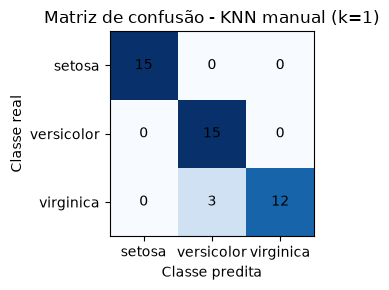

Tempo de predição manual: 0.043343 s

K = 3
Acurácia: 0.9556
Precisão (macro): 0.9608
Revocação (macro): 0.9556
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  2 13]]


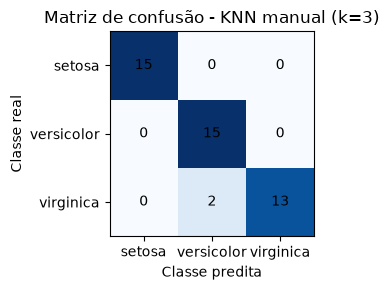

Tempo de predição manual: 0.045890 s

K = 5
Acurácia: 0.9778
Precisão (macro): 0.9792
Revocação (macro): 0.9778
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]


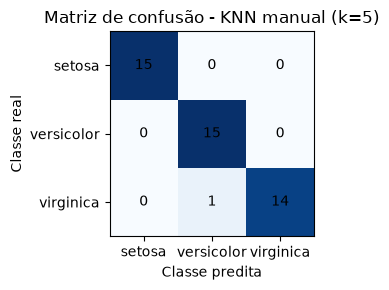

Tempo de predição manual: 0.046227 s

K = 7
Acurácia: 0.9556
Precisão (macro): 0.9608
Revocação (macro): 0.9556
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  2 13]]


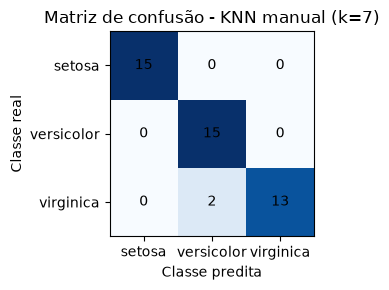

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import time

# Import da base de dados em formato frame
iris = load_iris(as_frame=True)
X = iris.data.to_numpy()
y = iris.target.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


def knn_manual_predict(X_train, y_train, sample, k):
    distances = []
    for i, x_train in enumerate(X_train):
        dist = euclidean_distance(x_train, sample)
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda item: item[0])
    neighbors = [label for _, label in distances[:k]]
    labels, counts = np.unique(neighbors, return_counts=True)
    return labels[np.argmax(counts)]


for k in [1, 3, 5, 7]:
    predictions = []
    start_time = time.perf_counter()
    for sample in X_test:
        predictions.append(knn_manual_predict(X_train, y_train, sample, k))
    elapsed_time = time.perf_counter() - start_time
    print(f"Tempo de predição manual: {elapsed_time:.6f} s")
    predictions = np.array(predictions)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='macro', zero_division=0)
    recall = recall_score(y_test, predictions, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, predictions, labels=[0, 1, 2])

    print(f"\nK = {k}")
    print(f"Acurácia: {accuracy:.4f}")
    print(f"Precisão (macro): {precision:.4f}")
    print(f"Revocação (macro): {recall:.4f}")
    print("Matriz de confusão:")
    print(cm)

    plt.figure(figsize=(4, 3))
    plt.imshow(cm, cmap='Blues')
    plt.title(f'Matriz de confusão - KNN manual (k={k})')
    plt.xticks([0, 1, 2], iris.target_names)
    plt.yticks([0, 1, 2], iris.target_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

    plt.xlabel('Classe predita')
    plt.ylabel('Classe real')
    plt.tight_layout()
    plt.show()


## Bloco 2: Implementação com scikit-learn e análise dos resultados

Neste segundo bloco será utilizada a implementação do algoritmo KNN disponível na biblioteca scikit-learn para comparar diretamente os resultados com a solução manual.

Serão executados os passos a seguir:
- criação do modelo KNN da biblioteca;
- treinamento com os dados de treinamento;
- predição sobre os dados de teste;
- cálculo da matriz de confusão;
- cálculo de precisão, revocação e acurácia;
- comparação dos resultados obtidos com a implementação manual.






K = 1
Tempo de treinamento + predição: 0.005151 s
Acurácia: 0.9333
Precisão (macro): 0.9444
Revocação (macro): 0.9333
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  3 12]]


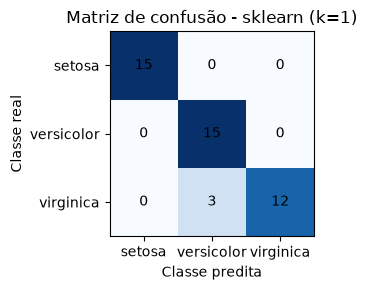


K = 3
Tempo de treinamento + predição: 0.004889 s
Acurácia: 0.9556
Precisão (macro): 0.9608
Revocação (macro): 0.9556
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  2 13]]


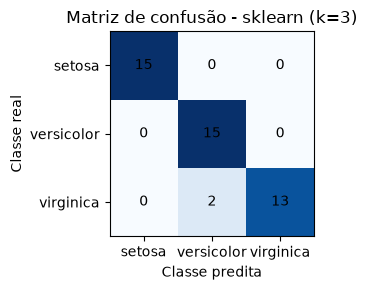


K = 5
Tempo de treinamento + predição: 0.005299 s
Acurácia: 0.9778
Precisão (macro): 0.9792
Revocação (macro): 0.9778
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]


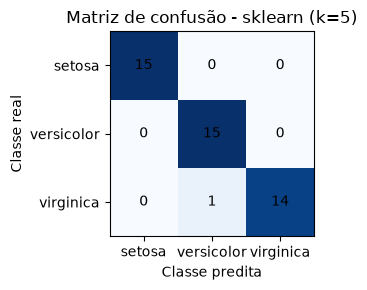


K = 7
Tempo de treinamento + predição: 0.004768 s
Acurácia: 0.9556
Precisão (macro): 0.9608
Revocação (macro): 0.9556
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  2 13]]


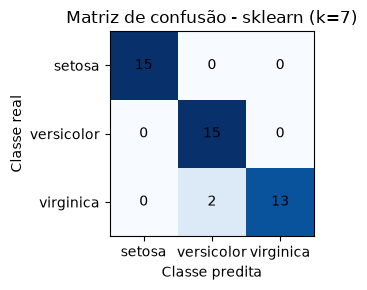

In [4]:
from sklearn.neighbors import KNeighborsClassifier
import time

for k in [1, 3, 5, 7]:
    model = KNeighborsClassifier(n_neighbors=k)
    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    elapsed_time = time.perf_counter() - start_time

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='macro', zero_division=0)
    recall = recall_score(y_test, predictions, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, predictions, labels=[0, 1, 2])

    print(f"\nK = {k}")
    print(f"Tempo de treinamento + predição: {elapsed_time:.6f} s")
    print(f"Acurácia: {accuracy:.4f}")
    print(f"Precisão (macro): {precision:.4f}")
    print(f"Revocação (macro): {recall:.4f}")
    print("Matriz de confusão:")
    print(cm)

    plt.figure(figsize=(4, 3))
    plt.imshow(cm, cmap='Blues')
    plt.title(f'Matriz de confusão - sklearn (k={k})')
    plt.xticks([0, 1, 2], iris.target_names)
    plt.yticks([0, 1, 2], iris.target_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

    plt.xlabel('Classe predita')
    plt.ylabel('Classe real')
    plt.tight_layout()
    plt.show()


## Observações sobre a comparação

A comparação entre os dois classificadores permite avaliar:
- a robustez da implementação manual;
- a precisão da solução baseada em biblioteca;
- a influência do parâmetro k no desempenho;
- eventuais diferenças em tempo de execução e qualidade da classificação.

Essa análise é essencial para concluir qual abordagem apresenta melhor desempenho para a base Iris.

Comparação lado a lado dos resultados:


,k,Acurácia manual,Acurácia sklearn,Precisão manual,Precisão sklearn,Revocação manual,Revocação sklearn,Tempo manual (s),Tempo sklearn (s),Diferença de acurácia,Diferença de precisão,Diferença de revocação,Diferença de tempo (s)
0,1,0.9333,0.9333,0.9444,0.9444,0.9333,0.9333,0.0405,0.0050,0.0,0.0,0.0,0.0355
1,3,0.9556,0.9556,0.9608,0.9608,0.9556,0.9556,0.0434,0.0042,0.0,0.0,0.0,0.0392
2,5,0.9778,0.9778,0.9792,0.9792,0.9778,0.9778,0.0412,0.0044,0.0,0.0,0.0,0.0368
3,7,0.9556,0.9556,0.9608,0.9608,0.9556,0.9556,0.0419,0.0045,0.0,0.0,0.0,0.0374



Maior diferença média nas métricas de qualidade: Acurácia
Diferença média: 0.0000


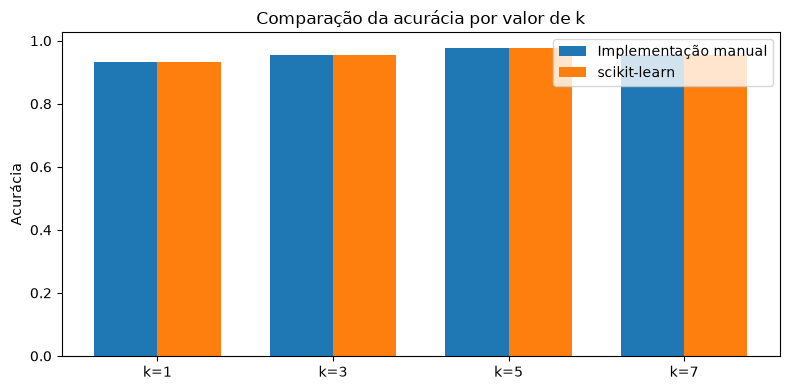

In [5]:
import pandas as pd

# Reúne as métricas dos dois classificadores para comparação direta.
resultados = []

for k_comparacao in [1, 3, 5, 7]:
    inicio_manual = time.perf_counter()
    previsoes_manuais = np.array([
        knn_manual_predict(X_train, y_train, amostra, k_comparacao)
        for amostra in X_test
    ])
    tempo_manual = time.perf_counter() - inicio_manual

    modelo_sklearn = KNeighborsClassifier(n_neighbors=k_comparacao)
    inicio_sklearn = time.perf_counter()
    modelo_sklearn.fit(X_train, y_train)
    previsoes_sklearn = modelo_sklearn.predict(X_test)
    tempo_sklearn = time.perf_counter() - inicio_sklearn

    resultados.append({
        'k': k_comparacao,
        'Acurácia manual': accuracy_score(y_test, previsoes_manuais),
        'Acurácia sklearn': accuracy_score(y_test, previsoes_sklearn),
        'Precisão manual': precision_score(y_test, previsoes_manuais, average='macro', zero_division=0),
        'Precisão sklearn': precision_score(y_test, previsoes_sklearn, average='macro', zero_division=0),
        'Revocação manual': recall_score(y_test, previsoes_manuais, average='macro', zero_division=0),
        'Revocação sklearn': recall_score(y_test, previsoes_sklearn, average='macro', zero_division=0),
        'Tempo manual (s)': tempo_manual,
        'Tempo sklearn (s)': tempo_sklearn
    })

comparacao = pd.DataFrame(resultados)
comparacao['Diferença de acurácia'] = abs(comparacao['Acurácia manual'] - comparacao['Acurácia sklearn'])
comparacao['Diferença de precisão'] = abs(comparacao['Precisão manual'] - comparacao['Precisão sklearn'])
comparacao['Diferença de revocação'] = abs(comparacao['Revocação manual'] - comparacao['Revocação sklearn'])
comparacao['Diferença de tempo (s)'] = abs(comparacao['Tempo manual (s)'] - comparacao['Tempo sklearn (s)'])

print('Comparação lado a lado dos resultados:')
display(comparacao.round(4))

diferencas_qualidade = {
    'Acurácia': comparacao['Diferença de acurácia'].mean(),
    'Precisão': comparacao['Diferença de precisão'].mean(),
    'Revocação': comparacao['Diferença de revocação'].mean()
}
maior_diferenca = max(diferencas_qualidade, key=diferencas_qualidade.get)
print(f'\nMaior diferença média nas métricas de qualidade: {maior_diferenca}')
print(f"Diferença média: {diferencas_qualidade[maior_diferenca]:.4f}")

coluna_manual = f'{maior_diferenca} manual'
coluna_sklearn = f'{maior_diferenca} sklearn'
posicoes = np.arange(len(comparacao))

plt.figure(figsize=(8, 4))
plt.bar(posicoes - 0.18, comparacao[coluna_manual], width=0.36, label='Implementação manual')
plt.bar(posicoes + 0.18, comparacao[coluna_sklearn], width=0.36, label='scikit-learn')
plt.xticks(posicoes, [f'k={valor}' for valor in comparacao['k']])
plt.ylabel(maior_diferenca)
plt.title(f'Comparação da {maior_diferenca.lower()} por valor de k')
plt.legend()
plt.tight_layout()
plt.show()


## Conclusão

A partir da comparação entre a implementação manual e a implementação do KNN com a biblioteca scikit-learn, é possível observar como o algoritmo funciona na prática e como pequenas mudanças no valor de k podem influenciar os resultados. Onde um número maior de vizinhos não garante um modelo mais assertivo, pelos testes é possível identificar que com k=5 que conseguimos um modelo preditivo com menos erro e quando elevamos os vizinhos a 7 tivemos um regresso no número de acertos.


Em geral, a implementação manual demonstra o funcionamento interno do classificador e ajuda a fixar os conceitos teóricos aprendidos em aula, enquanto a versão com biblioteca representa uma solução mais otimizada e prática para uso em projetos reais, sedno tempo a váriavel com maior diferença entre os dois modelos.

Por meio da análise das métricas de acurácia, precisão e revocação, além da matriz de confusão, é possível concluir que o KNN é uma técnica simples, eficiente e bastante útil para classificação de dados tabulares como a base Iris.

Este notebook foi estruturado para demonstrar o desenvolvimento completo da atividade, desde a ideia do algoritmo até a comparação dos resultados finais.
